In [1]:
import numpy as np
import torch
import quairkit as qkit
from quairkit import Circuit
from quairkit.database import *
from quairkit.operator import RZ, ChoiRepr, KrausRepr, StinespringRepr, Oracle
from quairkit.qinfo import *

import warnings
warnings.filterwarnings('ignore')

the diagram of a quantum circuit:


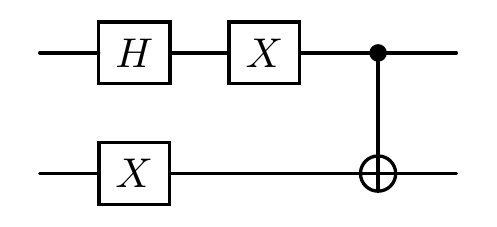

the total number of qubit of the circuit is 3


In [2]:
num_qubits = 3  # number of qubits
cir = Circuit(num_qubits) 
cir.h(0)  # Add Hadamard gate to qubit 0
cir.x([0, 1])  # Add X gate to qubit 0 and 1
cir.cx([0, 1])  # Add CNOT gate to qubit 0 and 1
print("the diagram of a quantum circuit:")
cir.plot()
print(f"the total number of qubit of the circuit is {cir.num_qubits}")

In [3]:
print(f"the unitary matrix of the circuit:\n{cir.matrix}")

the unitary matrix of the circuit:
tensor([[ 0.0000+0.j,  0.0000+0.j,  0.7071+0.j,  0.0000+0.j,  0.0000+0.j,  0.0000+0.j,
         -0.7071+0.j,  0.0000+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  0.0000+0.j,  0.7071+0.j,  0.0000+0.j,  0.0000+0.j,
          0.0000+0.j, -0.7071+0.j],
        [ 0.7071+0.j,  0.0000+0.j,  0.0000+0.j,  0.0000+0.j, -0.7071+0.j,  0.0000+0.j,
          0.0000+0.j,  0.0000+0.j],
        [ 0.0000+0.j,  0.7071+0.j,  0.0000+0.j,  0.0000+0.j,  0.0000+0.j, -0.7071+0.j,
          0.0000+0.j,  0.0000+0.j],
        [ 0.7071+0.j,  0.0000+0.j,  0.0000+0.j,  0.0000+0.j,  0.7071+0.j,  0.0000+0.j,
          0.0000+0.j,  0.0000+0.j],
        [ 0.0000+0.j,  0.7071+0.j,  0.0000+0.j,  0.0000+0.j,  0.0000+0.j,  0.7071+0.j,
          0.0000+0.j,  0.0000+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  0.7071+0.j,  0.0000+0.j,  0.0000+0.j,  0.0000+0.j,
          0.7071+0.j,  0.0000+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  0.0000+0.j,  0.7071+0.j,  0.0000+0.j,  0.0000+0.j,
          0.0000+

the diagram of the quantum circuit with more gates:


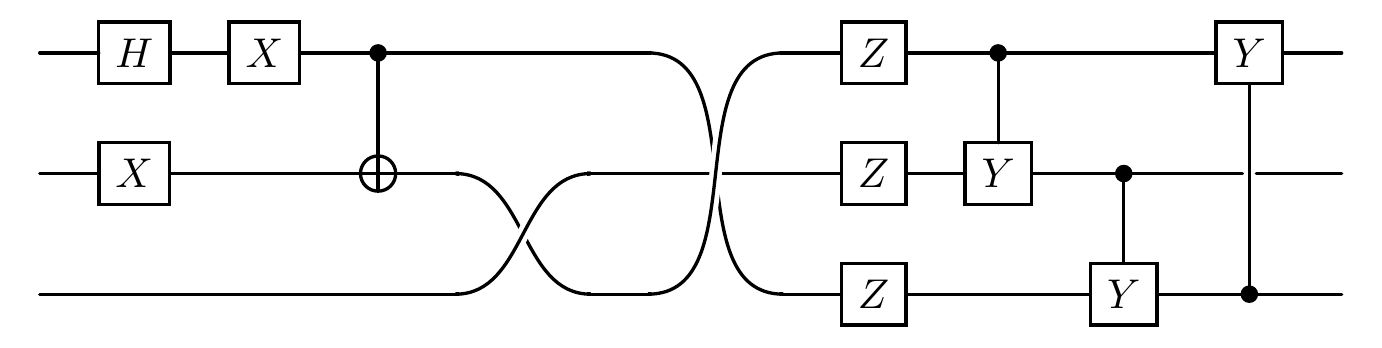

the total number of qubit of the circuit is 3


In [4]:
cir.swap([[1, 2], [0, 2]])  # Add SWAP gate to qubit 1 and 2, and qubit 0 and 2
cir.z()  # Add Z gate to all qubits
cir.cy()  # Add CY gate in cycle
print("the diagram of the quantum circuit with more gates:")
cir.plot()
print(f"the total number of qubit of the circuit is {cir.num_qubits}")

the diagram of a quantum circuit with parametrized gates:


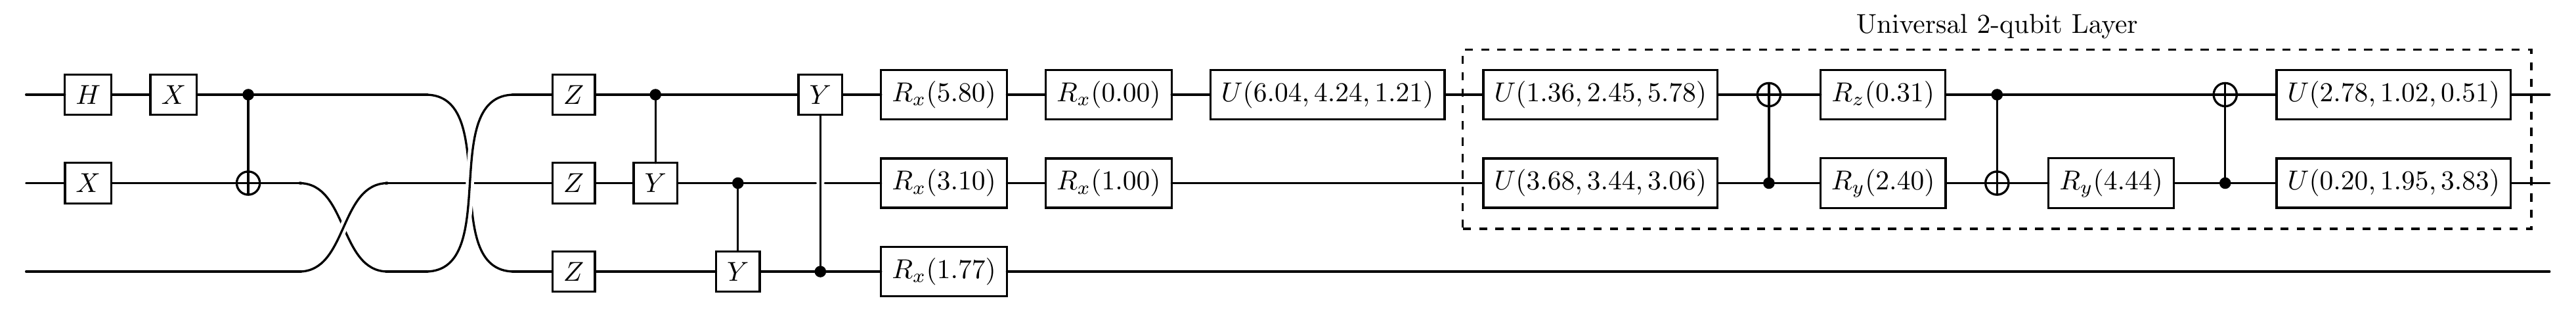

In [5]:
cir.rx() # Add Rx gate to all qubits with random parameters
cir.rx([0, 1], param=np.arange(2)) # Add RX gate to the first two qubits with specified parameters

cir.u3([0]) # Add universal single qubit gate
cir.universal_two_qubits([0, 1]) # Add universal two qubits gate
print("the diagram of a quantum circuit with parametrized gates:")
cir.plot()

the diagram of a quantum circuit with a custom gate:


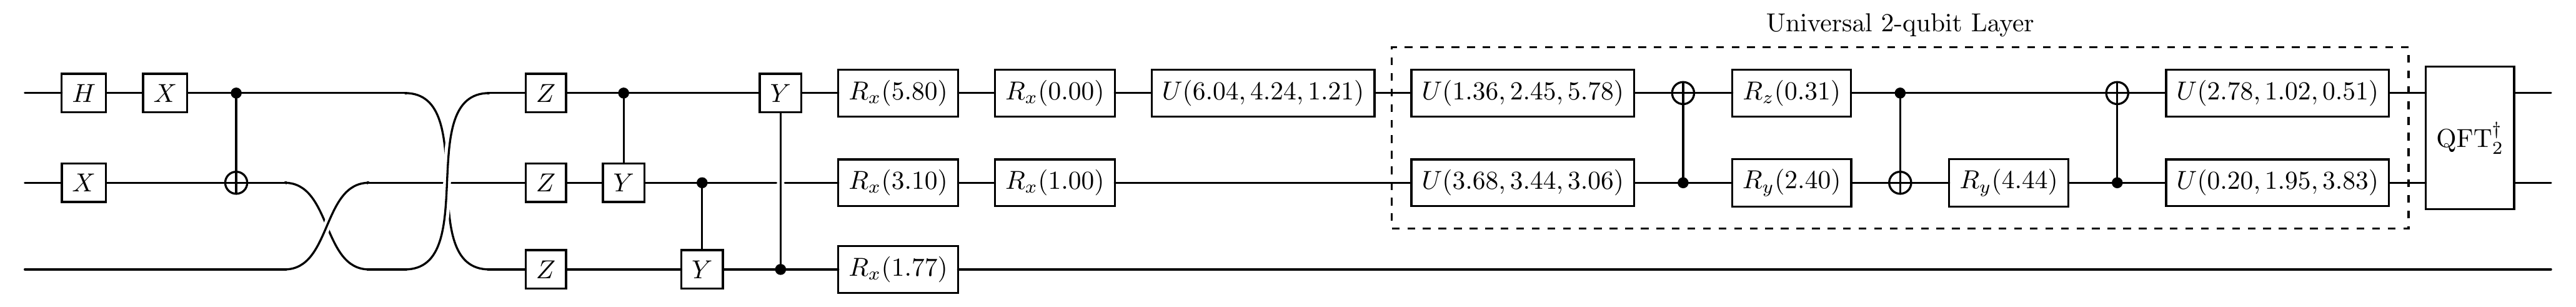

In [6]:
qft_mat = qft_matrix(num_qubits=2)  # construct a 2-qubit quantum Fourier transformation (QFT) operator
qft_inverse = dagger(qft_mat)  # get the inverse QFT

cir.oracle(qft_inverse, qubits_idx=[0, 1], latex_name=r'\text{QFT}_{2}^{\dagger}')  # add custom gate
print("the diagram of a quantum circuit with a custom gate:")
cir.plot()

the diagram of a quantum circuit with custom gates:


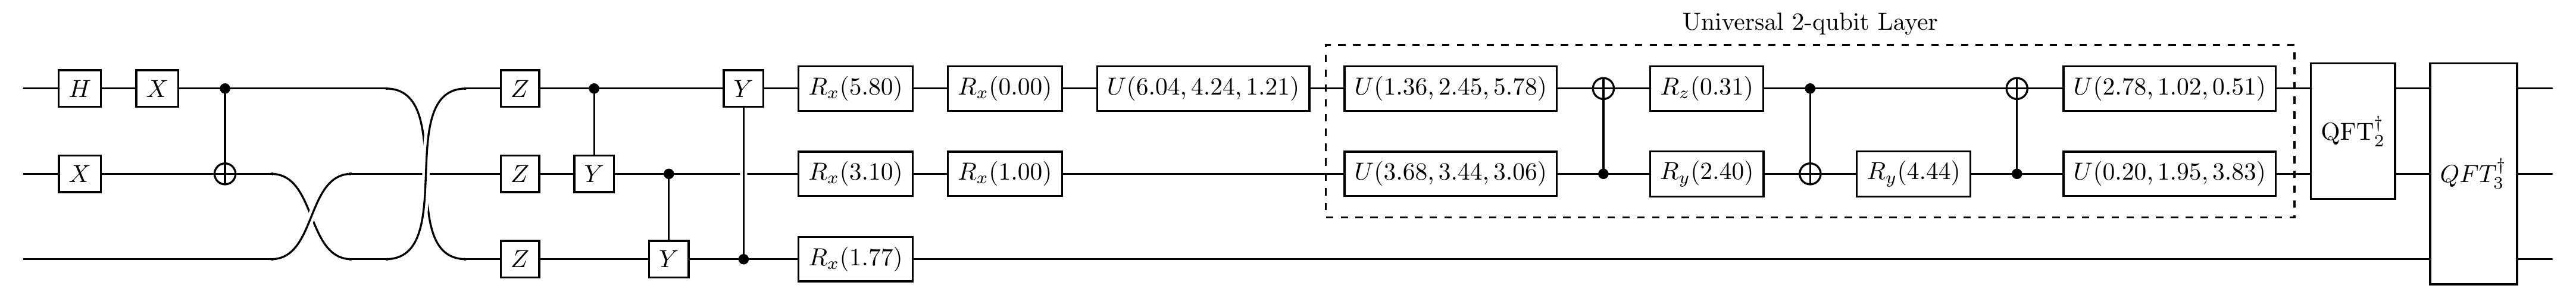

In [7]:
qft_mat = qft_matrix(num_qubits=3)  # construct a 3-qubit quantum Fourier transformation (QFT) operator
qft_inverse = dagger(qft_mat)  # get the inverse QFT
custom_unitary = Oracle(qft_inverse, system_idx=list(range(3)), gate_info={"tex": r'QFT_{3}^{\dagger}'})
cir.append(custom_unitary)
print("the diagram of a quantum circuit with custom gates:")
cir.plot()

the diagram of a quantum circuit with a controlled custom gate:


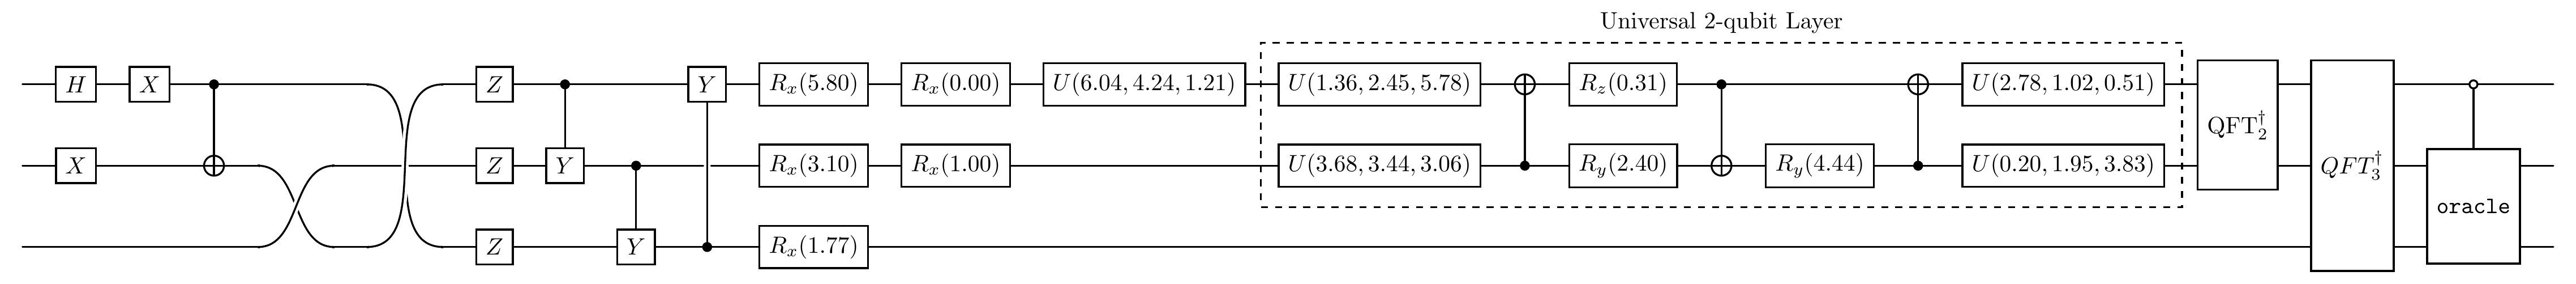

In [8]:
cir.oracle(random_unitary(num_qubits=2), qubits_idx=[0, 1, 2], control_idx=0, gate_name="O")

print("the diagram of a quantum circuit with a controlled custom gate:")
cir.plot()

In [9]:
cir.depolarizing(prob=0.1, qubits_idx=[0])  # add a depolarizing channel (with probability 0.1) to qubit 0
cir.bit_phase_flip(0.2)  # Add bit-phase flip channels (with probability 0.2) to all qubits
rho = random_state(num_qubits=3)
replacement_choi_repr = replacement_choi(rho)  # replacement channel in Choi representation
cir.choi_channel(replacement_choi_repr, system_idx=[0, 1, 2])  # add replacement channel in Choi representation

reset_kraus_repr = reset_kraus([0.1, 0.2])  # reset channel in Kraus representation
cir.kraus_channel(reset_kraus_repr, system_idx=2)  # add reset channel in Kraus representation

random_stin_repr = random_channel(num_systems=1, target="stinespring")  # random single-qubit channel in Stinespring representation
cir.stinespring_channel(random_stin_repr, system_idx=1)  # add random channel in Stinespring representation


In [10]:
choi_op = random_channel(num_systems=2, target="choi")
choi_repr = ChoiRepr(choi_op, system_idx=[1, 2])
cir.append(choi_repr)

kraus_op = random_channel(num_systems=1, target="kraus")
kraus_repr = KrausRepr(kraus_op, system_idx=0)
cir.append(kraus_repr)

stine_op = random_channel(num_systems=3, target="stinespring")
stine_repr = StinespringRepr(stine_op, system_idx=[0, 1, 2])
cir.append(stine_repr)

Circuit(
  (0): H()
  (1): X()
  (2): CNOT()
  (3): SWAP()
  (4): Z()
  (5): CY()
  (6): RX()
  (7): RX()
  (8): U3()
  (9): Universal2(
    (0): U3()
    (1): CNOT()
    (2): RZ()
    (3): RY()
    (4): CNOT()
    (5): RY()
    (6): CNOT()
    (7): U3()
  )
  (10): Oracle()
  (11): Oracle()
  (12): ControlOracle()
  (13): Depolarizing()
  (14): BitPhaseFlip()
  (15): ChoiRepr()
  (16): KrausRepr()
  (17): StinespringRepr()
  (18): ChoiRepr()
  (19): KrausRepr()
  (20): StinespringRepr()
)

the diagram of a quantum circuit with different kinds of layers:


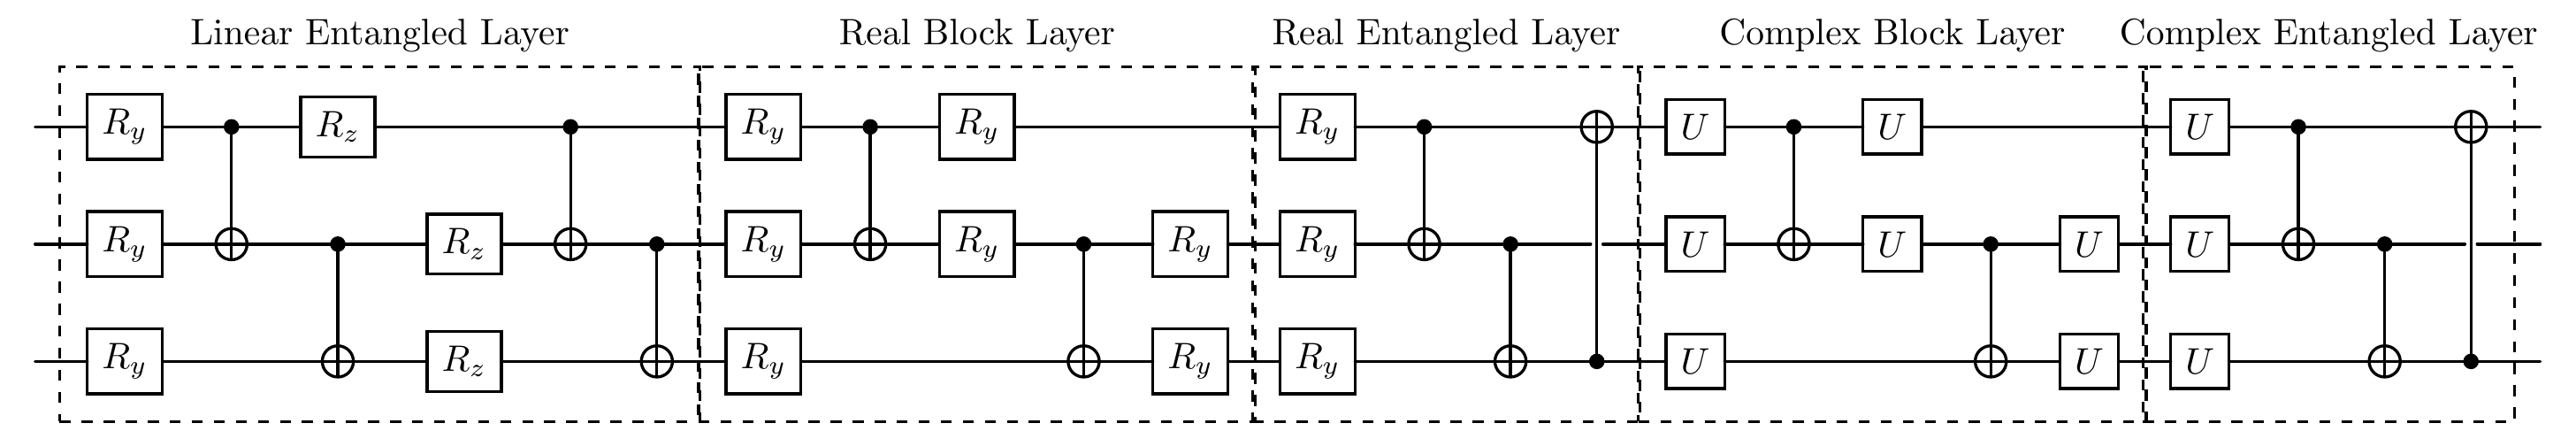

In [11]:
num_qubits = 3  # number of qubits
cir = Circuit(num_qubits)
cir.linear_entangled_layer(depth=1)  # add a linear entangled layer
cir.real_block_layer(depth=1)  # add real block layers in depth 2
cir.real_entangled_layer(depth=1)  # add a real entangled layer

cir.complex_block_layer(depth=1)  # add a complex block layer 
cir.complex_entangled_layer(depth=1)  # add a complex entangled layer

print("the diagram of a quantum circuit with different kinds of layers:")
cir.plot(style='compact')

In [12]:
print("The unitary matrix of the first layer is\n", cir[0].matrix)

The unitary matrix of the first layer is
 tensor([[ 0.6000-2.6951e-01j, -0.6813+3.0604e-01j,  0.0345-1.5477e-02j,
         -0.0391+1.7574e-02j, -0.0478+2.1470e-02j,  0.0543-2.4380e-02j,
         -0.0027+1.2329e-03j,  0.0031-1.4000e-03j],
        [ 0.7340-1.3804e-01j,  0.6464-1.2156e-01j,  0.0422-7.9267e-03j,
          0.0371-6.9807e-03j, -0.0585+1.0996e-02j, -0.0515+9.6840e-03j,
         -0.0034+6.3147e-04j, -0.0030+5.5610e-04j],
        [-0.0222+3.0560e-02j,  0.0252-3.4701e-02j,  0.3865-5.3217e-01j,
         -0.4389+6.0429e-01j,  0.0018-2.4345e-03j, -0.0020+2.7644e-03j,
         -0.0308+4.2395e-02j,  0.0350-4.8140e-02j],
        [-0.0164+3.9638e-02j, -0.0144+3.4907e-02j,  0.2852-6.9026e-01j,
          0.2512-6.0787e-01j,  0.0013-3.1577e-03j,  0.0011-2.7808e-03j,
         -0.0227+5.4988e-02j, -0.0200+4.8425e-02j],
        [ 0.0585+1.0996e-02j,  0.0515+9.6840e-03j,  0.0034+6.3147e-04j,
          0.0030+5.5610e-04j,  0.7340+1.3804e-01j,  0.6464+1.2156e-01j,
          0.0422+7.9267e-03j, 

The quantum circuit after adding gates is: 


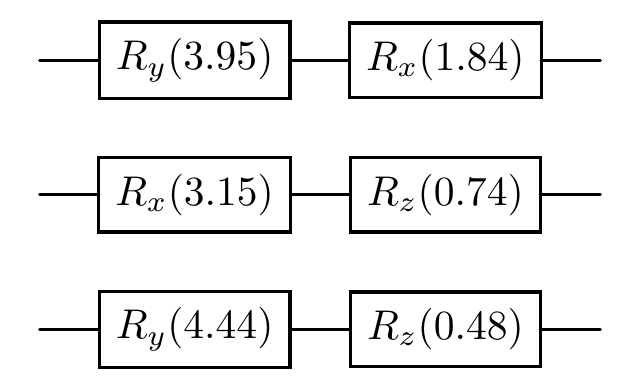

The quantum circuit after removing gates is:


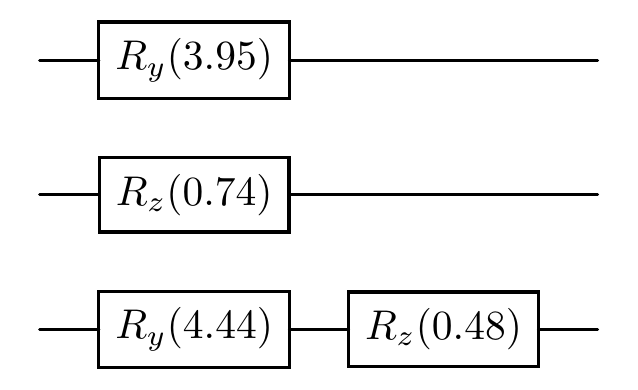

In [13]:
cir = Circuit(num_qubits=3)
# Set parameters and customize quantum gates. Here we select Ry, Rx, Rz gates
param = np.random.rand(2)

# By default, randomly generates a set of parameters
rz_gate = RZ(param=param, qubits_idx=[1, 2])

# Add quantum gates
cir.ry([0, 2])
cir.rx([0, 1])
cir.insert(index=2, module=rz_gate)  # index where to insert

print("The quantum circuit after adding gates is: ")
cir.plot()

cir.pop(1)  # Remove Rx gate
print("The quantum circuit after removing gates is:")
cir.plot()

In [14]:
output_state = cir()  # Run the circuit with initial state |0>
print("the output state for inputting zero state is:", output_state)

rho = random_state(num_qubits=3)
output_state = cir(rho)  # Run the circuit with initial state sigma
print("the output state for inputting state rho is:", output_state)

the output state for inputting zero state is: 
-----------------------------------------------------
 Backend: default-pure
 System dimension: [2, 2, 2]
 System sequence: [1, 2, 0]
[ 0.19-0.14j -0.46+0.32j -0.31+0.04j  0.73-0.1j   0.  +0.j    0.  +0.j
  0.  +0.j    0.  +0.j  ]
-----------------------------------------------------

the output state for inputting state rho is: 
-----------------------------------------------------
 Backend: default-mixed
 System dimension: [2, 2, 2]
 System sequence: [1, 2, 0]
[[ 0.09-0.j    0.05+0.03j -0.05+0.01j  0.1 +0.04j -0.02-0.01j -0.05-0.04j
  -0.06-0.06j  0.01-0.03j]
 [ 0.05-0.03j  0.13+0.j   -0.02-0.j    0.06+0.01j -0.04-0.01j -0.03-0.03j
  -0.08-0.02j  0.03+0.01j]
 [-0.05-0.01j -0.02+0.j    0.13+0.j   -0.11-0.02j  0.05+0.01j  0.01+0.09j
   0.03+0.06j -0.03-0.02j]
 [ 0.1 -0.04j  0.06-0.01j -0.11+0.02j  0.26+0.j   -0.02+0.05j -0.08-0.02j
  -0.14-0.08j -0.01-0.03j]
 [-0.02+0.01j -0.04+0.01j  0.05-0.01j -0.02-0.05j  0.07+0.j    0.03+0.06j
  -0.01+

In [15]:
print("the circuit depth is", cir.depth, "\n")

print("the gate history of the circuit is\n", cir.operator_history)

the circuit depth is 2 

the gate history of the circuit is
 [{'uid': '078f73ef-5726-4fec-bc8b-b6d04e2c0575', 'name': 'ry', 'type': 'gate', 'tex': 'R_{y}', 'api': 'ry', 'param_sharing': False, 'plot_width': 0.9, 'system_idx': [[0], [2]], 'param': Parameter containing:
tensor([[[3.9484]],

        [[4.4434]]], requires_grad=True), 'matrix': tensor([[[-0.3926+0.j, -0.9197+0.j],
         [ 0.9197+0.j, -0.3926+0.j]],

        [[-0.6059+0.j, -0.7955+0.j],
         [ 0.7955+0.j, -0.6059+0.j]]], grad_fn=<SqueezeBackward0>)}, {'uid': '0cdde9bd-cc22-437e-bc8c-301114824d9e', 'name': 'rz', 'type': 'gate', 'tex': 'R_{z}', 'api': 'rz', 'param_sharing': False, 'plot_width': 0.9, 'system_idx': [[1], [2]], 'param': tensor([[[0.7445]],

        [[0.4832]]]), 'matrix': tensor([[[0.9315-0.3637j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.9315+0.3637j]],

        [[0.9710-0.2393j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.9710+0.2393j]]])}]


In [16]:
print("the trainable parameters of entire circuit are", cir.param)

cir.update_param(torch.ones_like(cir.param))  # update the parameters of the circuit
print("the updated trainable parameters of entire circuit are", cir.param)

the trainable parameters of entire circuit are tensor([3.9484, 4.4434])
the updated trainable parameters of entire circuit are tensor([1., 1.])


In [17]:
qkit.print_info()


---------VERSION---------
quairkit: 0.4.4
torch: 2.11.0+cu130
torch cuda: 13.0
numpy: 2.3.5
scipy: 1.17.1
matplotlib: 3.10.8
---------SYSTEM---------
Python version: 3.13.9
OS: Linux
OS version: #107-Ubuntu SMP PREEMPT_DYNAMIC Fri Mar 13 19:51:50 UTC 2026
---------DEVICE---------
CPU:  Intel(R) Core(TM) i7-4770 CPU @ 3.40GHz
GPU: (0) NVIDIA GeForce GTX 1650
